<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/notebooks/parameter_sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parameter sweep: repulsion strength, per-gene cap, and the β prior

This notebook measures how sensitive CellSweep is to its regularization settings:

* **ρ** (`repulsion_strength`): how strongly cell-type profiles are pushed away from the ambient
  profile. Repulsion stays on through both training stages.
* **cap** (`max_frac_gene_repulsion`): the largest fraction of a gene's expected count that one
  repulsion step may remove. ρ and the cap interact: together they set how hard repulsion pushes,
  especially on genes that are abundant in the ambient profile.
* **κ** (`beta_prior_strength`): the weight of the Beta prior on the global contamination fraction β,
  as a fraction of the total counts (prior mode `beta_prior_mode = 0.01`).

The sweeps are centered on the model's defaults (ρ = 1e-3, κ = 1e-2, cap = 0.25), chosen from these results:

1. **Coarse ρ × cap grid**, each setting run with the default stopping rule *and* to convergence
   (3,000 iterations, tight tolerances). A setting is only useful if both runs agree.
2. **Dense ρ × cap grid** at low ρ and caps 0.2–0.35, default stopping only (where over-correction sets in).
3. **κ sweep** at the default ρ and cap, both stopping modes.
4. **Extra runs** at an intermediate cap (0.25) with larger ρ, both stopping modes, to check how much
   margin there is before repulsion over-corrects.

Results are scored against the ground truth each dataset offers:

| dataset | ground truth | noise removed | signal kept |
|---|---|---|---|
| `hgmm_12k` | species of each read (human–mouse mixture) | cross-species counts | same-species counts |
| `pbmc8k` | canonical immune markers | off-target marker counts | on-target marker counts; DC contamination as an over-correction flag |
| `kidney_nuclei_10k` | proximal tubule (PT) markers | PT markers in non-PT cells | PT markers in PT cells |
| `janssen_nuc2/3` | genotype (Janssen et al. 2023, *Genome Biol.* 24:140) | Kendall τ / RMSLE vs per-nucleus background; PT markers in non-PT nuclei | PT markers in PT nuclei |

The notebook is self-contained: any input it can't find is downloaded and prepared, and anything
already on disk at the locations the other notebooks use is reused. The Janssen metadata is stored
in Seurat `.RDS` files and needs `Rscript` on `PATH` (base R only). Remove the two Janssen entries
from `datasets` if R isn't available.

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import contextlib
import io
import os
import re
import subprocess
import time
import urllib.request
import zipfile

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy.stats import kendalltau

import cellsweep.utils as cs_utils
from cellsweep import denoise_count_matrix

cellsweep_dir = os.path.dirname(os.path.abspath(""))

In [3]:
datasets = ["hgmm_12k", "pbmc8k", "kidney_nuclei_10k", "janssen_nuc2", "janssen_nuc3"]

default = dict(rho=1e-3, kappa=1e-2, cap=0.25)  # the model's defaults: the reference setting in every plot

# 1. coarse rho x cap grid, both stopping modes
coarse_rho = [1e-5, 3e-5, 5e-5, 1e-4, 3e-4, 1e-3]
coarse_cap = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5]
# 2. dense rho x cap grid around the candidate default, default stopping only
dense_rho = [2e-5, 3e-5, 5e-5, 7e-5, 1e-4]
dense_cap = [0.2, 0.25, 0.3, 0.35]
# 3. beta prior strength at the candidate rho and cap, both stopping modes
kappa_grid = [0, 1e-3, 1e-2, 3e-2]
# 4. extra: an intermediate cap at larger rho, both stopping modes (checks the margin to over-correction)
extra_rho = [1e-4, 3e-4, 1e-3]
extra_cap = [0.25]

# Janssen inputs: split the authors' PT label by their Seurat clusters at this resolution (None keeps the
# authors' coarse labels); PT clusters with fewer than janssen_min_cluster nuclei are pooled into PT_other
janssen_label_resolution = 0.5
janssen_min_cluster = 50

modes = {
    "default": {},                                          # the model's own stopping rule
    "long": dict(tol_p=1e-8, tol_f=1e-8, max_iter=3000),    # run to convergence
}

threads = 8
overwrite = False   # rebuild inputs and rerun settings that already exist
quick = False       # True: only the default setting at default stopping (a fast end-to-end check)

data_root = os.path.join(cellsweep_dir, "notebooks", "data")
sweep_data_dir = os.path.join(data_root, "parameter_sweep")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "parameter_sweep")
log_dir = os.path.join(out_dir, "logs")
results_csv = os.path.join(out_dir, "results.csv")
for d in (sweep_data_dir, out_dir, log_dir):
    os.makedirs(d, exist_ok=True)

## Prepare inputs

Each dataset is prepared once and cached. Every step first checks the location the other notebooks
use (`benchmarking.ipynb` for the 10x datasets, `janssen_snrna.ipynb` for Janssen) and reuses
anything it finds.

**10x datasets** are prepared the way `benchmarking.ipynb` prepares them, using each dataset's config
in `notebooks/config/`:
1. Call barcodes below the knee-plot cutoff at `expected_cells` non-cellular.
2. Label cell types. hgmm_12k uses species plus human–mouse doublet calls; the others use CellTypist.

In [4]:
def download(url, path):
    if os.path.exists(path):
        return "reused"
    os.makedirs(os.path.dirname(path), exist_ok=True)
    print(f"  downloading {url}")
    urllib.request.urlretrieve(url, path + ".part")
    os.replace(path + ".part", path)
    return "downloaded"


def prepare_10x(ds):
    """Raw 10x matrix with is_empty and celltype (and is_doublet for hgmm), as in benchmarking.ipynb."""
    out = os.path.join(sweep_data_dir, f"{ds}_input.h5ad")
    if os.path.exists(out) and not overwrite:
        print(f"{ds}: reused {out}")
        return out
    cfg = cs_utils.load_dataset_yaml(os.path.join(cellsweep_dir, "notebooks", "config", f"{ds}.yaml"))
    raw_path = os.path.join(data_root, ds, os.path.basename(cfg["adata_raw_url"]))
    print(f"{ds}: raw matrix {download(cfg['adata_raw_url'], raw_path)} ({raw_path})")

    adata = cs_utils.load_adata(raw_path)
    adata.var_names_make_unique()
    expected_cells = cfg["expected_cells"]
    umi_cutoff = cs_utils.knee_plot(adata, expected_cells=expected_cells, show=False)
    adata = cs_utils.infer_empty_droplets(adata, method="threshold", umi_cutoff=umi_cutoff)

    if ds == "hgmm_12k":
        is_h = (adata.var["genome"] == "hg19").values
        h = np.asarray(adata.X[:, is_h].sum(axis=1)).ravel()
        m = np.asarray(adata.X[:, ~is_h].sum(axis=1)).ravel()
        adata.obs["celltype"] = np.where(h >= m, "hg19", "mm10")
        sc.pp.filter_cells(adata, min_counts=1)
        adata = cs_utils.detect_doublets_human_mouse(adata, fraction_doublet=cfg["fraction_doublet"], plot_empty=False,
                                                     umi_cutoff=umi_cutoff, expected_cells=expected_cells, show=False)
    else:
        adata = cs_utils.determine_cell_types(adata, model_pkl=cfg["model_pkl"], filter_empty=True,
                                              expected_cells=expected_cells, celltypist_convert=cfg["celltypist_convert"],
                                              celltypist_map_file=cfg["celltypist_map_file"])

    adata.uns["umi_cutoff"] = float(umi_cutoff)
    adata.write_h5ad(out)
    print(f"{ds}: built {out}")
    return out

**Janssen et al. (2023)** pooled kidneys from three mouse strains before droplet capture. Reads that
carry a foreign allele are background, which gives a per-nucleus background estimate (`bRNA`) for
the CAST nuclei. The inputs are built the same way `janssen_snrna.ipynb` builds them:
* the authors' called nuclei and cell types,
* every other barcode with 0 < UMI < 100 treated as non-cellular,
* the rest dropped.

The authors' proximal-tubule (PT) label covers most nuclei and several distinct PT populations. With
that coarse label, CellSweep's burn-in moves hundreds of poorly fit PT nuclei into a nearly empty
cell type (and warns about it), and those nuclei get poorly determined contamination estimates. As
label-based methods are best given labels at the resolution of the data, the sweep splits PT by the
authors' own Seurat clusters (`janssen_label_resolution`; `None` restores the coarse labels). Scores
are always computed with the authors' labels, so "PT" still means every PT nucleus.

In [5]:
JANSSEN_DIR = os.path.join(data_root, "janssen2023")
JANSSEN_ZENODO = "https://zenodo.org/records/7328632/files"
JANSSEN_EMPTY_UMI = 100
PT_MARKERS = ["Slc34a1", "Miox", "Pck1", "Slc4a4", "Ttc36", "Lrp2", "Fbp1", "Cyp2e1", "Fut9", "Khk"]
CONSTITUTIVE = ["Malat1", "Fth1", "Ftl1", "Tpt1", "Psap", "App"]

R_EXPORT = r"""
suppressWarnings({
  for (d in commandArgs(TRUE)) {
    md <- as.data.frame(attr(readRDS(file.path(d, "seurat.RDS")), "meta.data"))
    md$cell <- rownames(md)
    write.csv(md, file.path(d, "seurat_metadata.csv"), row.names = FALSE)
  }
})
"""


def prepare_janssen(rep):
    rep_dir = os.path.join(JANSSEN_DIR, rep)
    out = os.path.join(rep_dir, f"adata_raw_empty{JANSSEN_EMPTY_UMI}.h5ad")
    if os.path.exists(out) and not overwrite:
        print(f"janssen_{rep}: reused {out}")
        return out

    if not os.path.isdir(rep_dir):
        zip_path = os.path.join(JANSSEN_DIR, f"{rep}.zip")
        download(f"{JANSSEN_ZENODO}/{rep}.zip?download=1", zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(JANSSEN_DIR)

    md_path = os.path.join(rep_dir, "seurat_metadata.csv")
    if not os.path.exists(md_path):
        script = os.path.join(JANSSEN_DIR, "export_metadata.R")
        with open(script, "w") as f:
            f.write(R_EXPORT)
        subprocess.run(["Rscript", script, rep_dir], check=True)
    md_df = pd.read_csv(md_path).set_index("cell")

    adata = cs_utils.load_adata(os.path.join(rep_dir, "raw_feature_bc_matrix.h5"))
    adata.var_names_make_unique()
    total = np.asarray(adata.X.sum(axis=1)).ravel()
    is_cell = np.asarray(adata.obs_names.isin(md_df.index))
    keep = is_cell | ((total > 0) & (total < JANSSEN_EMPTY_UMI))
    adata = adata[keep].copy()
    adata.obs["is_empty"] = ~np.asarray(adata.obs_names.isin(md_df.index))
    adata.obs["celltype"] = md_df["celltype"].reindex(adata.obs_names).fillna("empty").values
    for col in ["Strain", "bRNA", "nSNP"]:
        adata.obs[col] = md_df[col].reindex(adata.obs_names).values
    adata.uns["umi_cutoff"] = float(JANSSEN_EMPTY_UMI)
    adata.write_h5ad(out)
    print(f"janssen_{rep}: built {out} ({int(is_cell.sum()):,} nuclei, {int(adata.obs['is_empty'].sum()):,} non-cellular)")
    return out


def janssen_sweep_input(rep):
    # the prepared matrix with the authors' PT label split by their Seurat clusters (see config)
    base = prepare_janssen(rep)
    if janssen_label_resolution is None:
        return base
    out = os.path.join(sweep_data_dir, f"janssen_{rep}_input_res{janssen_label_resolution:g}_min{janssen_min_cluster}.h5ad")
    if os.path.exists(out) and not overwrite:
        print(f"janssen_{rep}: reused {out}")
        return out
    adata = ad.read_h5ad(base)
    md_df = pd.read_csv(os.path.join(JANSSEN_DIR, rep, "seurat_metadata.csv")).set_index("cell")
    author = adata.obs["celltype"].astype(str).values
    clusters = md_df[f"RNA_snn_res.{janssen_label_resolution:g}"].reindex(adata.obs_names)
    is_pt = author == "PT"
    sizes = clusters[is_pt].value_counts()
    keep = set(sizes[sizes >= janssen_min_cluster].index)
    label = author.copy()
    label[is_pt] = [f"PT_c{int(c)}" if c in keep else "PT_other" for c in clusters[is_pt]]
    adata.obs["celltype_author"] = author
    adata.obs["celltype"] = label
    adata.write_h5ad(out)
    print(f"janssen_{rep}: built {out} (PT split into {len(set(label[is_pt]))} labels)")
    return out

In [6]:
input_paths = {}
for ds in datasets:
    input_paths[ds] = janssen_sweep_input(ds.split("_")[1]) if ds.startswith("janssen_") else prepare_10x(ds)

for ds, path in input_paths.items():
    obs = ad.read_h5ad(path, backed="r").obs
    cells = ~obs["is_empty"].astype(bool)
    print(f"{ds:18s} {int(cells.sum()):7,} cells  {int((~cells).sum()):9,} non-cellular  "
          f"cell types: {obs.loc[cells, 'celltype'].nunique()}")

hgmm_12k: reused /Users/mcaskey/Desktop/cellsweep/notebooks/data/parameter_sweep/hgmm_12k_input.h5ad
pbmc8k: reused /Users/mcaskey/Desktop/cellsweep/notebooks/data/parameter_sweep/pbmc8k_input.h5ad
kidney_nuclei_10k: reused /Users/mcaskey/Desktop/cellsweep/notebooks/data/parameter_sweep/kidney_nuclei_10k_input.h5ad
janssen_nuc2: reused /Users/mcaskey/Desktop/cellsweep/notebooks/data/janssen2023/nuc2/adata_raw_empty100.h5ad
janssen_nuc2: reused /Users/mcaskey/Desktop/cellsweep/notebooks/data/parameter_sweep/janssen_nuc2_input_res0.5_min50.h5ad
janssen_nuc3: reused /Users/mcaskey/Desktop/cellsweep/notebooks/data/janssen2023/nuc3/adata_raw_empty100.h5ad
janssen_nuc3: reused /Users/mcaskey/Desktop/cellsweep/notebooks/data/parameter_sweep/janssen_nuc3_input_res0.5_min50.h5ad


hgmm_12k            12,820 cells    664,623 non-cellular  cell types: 2


pbmc8k               8,381 cells    728,899 non-cellular  cell types: 7


kidney_nuclei_10k   10,321 cells    547,669 non-cellular  cell types: 5


janssen_nuc2        16,714 cells  1,462,006 non-cellular  cell types: 26


janssen_nuc3         4,266 cells  1,461,582 non-cellular  cell types: 21


## Scoring

Every run records β̂, the median α over cells, the fraction of counts removed from cells, the
number of EM iterations, and the runtime. Dataset-specific scores:

* **hgmm_12k:** non-empty, non-doublet cells, with each cell's species fixed from its raw counts.
  *Noise removed* is the fraction of cross-species counts removed; *signal kept* is the fraction of
  same-species counts kept (as in `benchmarking.ipynb`). Same-species counts include some
  same-species ambient RNA, so signal kept is expected to stay a little below 1.
* **pbmc8k:** count-weighted fraction of off-target marker counts removed and of on-target counts
  kept, for the monocyte/DC markers used in `benchmarking.ipynb`. S100A8 and S100A9 count as
  on-target in monocytes *and* DCs, which express them. Also reported: the fraction kept of broadly
  expressed controls (PTPRC, ACTB, B2M), and the median α of DCs relative to all other cells. DCs are
  a small population that expresses genes abundant in the ambient profile, and when repulsion is too
  strong their α inflates well above every other cell type's. The DC ratio is relative: when every
  cell type is over-corrected it can look normal again, so read it together with controls kept.
* **kidney_nuclei_10k:** PT markers (LRP2, CUBN, SLC34A1) kept in PT cells and removed from other
  cells, plus the fraction removed per cell type. The dataset's TAL label marks small,
  mitochondria-rich barcodes whose profile matches the ambient profile, not TAL nuclei, so it is
  reported but not used as a score.
* **Janssen:** per-nucleus fraction removed (non-mitochondrial genes) against the genotype estimate,
  using Kendall τ and RMSLE as Janssen et al. define them. Also the removal of PT-marker counts from
  non-PT nuclei (background, since the background RNA is mostly PT RNA) and the fraction of PT-marker
  counts kept in PT nuclei (a calibrated method keeps about 1 − the background fraction).

In [7]:
PBMC_ON_TARGET = {"S100A8": {"Monocytes", "DC"}, "S100A9": {"Monocytes", "DC"},
                  "LYZ": {"Monocytes", "DC", "pDC"}, "CST3": {"Monocytes", "DC", "pDC"}}
PBMC_CONTROLS = ["PTPRC", "ACTB", "B2M"]
KIDNEY_PT_MARKERS = ["LRP2", "CUBN", "SLC34A1"]


def _gene_sums(m, rows, cols):
    return np.asarray(m[rows][:, cols].sum(axis=0)).ravel()


def score_common(out, log_path, seconds):
    cells = ~out.obs["is_empty"].astype(bool).values
    raw, den = out.layers["raw"][cells], out.X[cells]
    with open(log_path) as f:
        n_iter = len(re.findall(r"EM Iter", f.read()))
    return dict(beta_hat=float(out.uns["beta_hat"]),
                median_alpha=float(np.median(out.obs["alpha_hat"].values[cells])),
                removed=float(1 - den.sum() / raw.sum()), iterations=n_iter, seconds=round(seconds, 1))


def score_hgmm(out):
    keep = ~out.obs["is_empty"].astype(bool).values & ~out.obs["is_doublet"].astype(bool).values
    is_h = (out.var["genome"] == "hg19").values
    raw, den = out.layers["raw"][keep], out.X[keep]
    rh, rm = np.asarray(raw[:, is_h].sum(1)).ravel(), np.asarray(raw[:, ~is_h].sum(1)).ravel()
    dh, dm = np.asarray(den[:, is_h].sum(1)).ravel(), np.asarray(den[:, ~is_h].sum(1)).ravel()
    human = rh >= rm
    return dict(hgmm_noise_removed=1 - (dm[human].sum() + dh[~human].sum()) / (rm[human].sum() + rh[~human].sum()),
                hgmm_signal_kept=(dh[human].sum() + dm[~human].sum()) / (rh[human].sum() + rm[~human].sum()))


def score_pbmc(out):
    cells = ~out.obs["is_empty"].astype(bool).values
    ct = out.obs["celltype"].astype(str).values[cells]
    raw, den = out.layers["raw"][cells], out.X[cells]
    genes = [g for g in PBMC_ON_TARGET if g in out.var_names]
    gi = [out.var_names.get_loc(g) for g in genes]
    on_raw = on_den = off_raw = off_den = 0.0
    for g, j in zip(genes, gi):
        on = np.isin(ct, list(PBMC_ON_TARGET[g]))
        r, d = np.asarray(raw[:, j].todense()).ravel(), np.asarray(den[:, j].todense()).ravel()
        on_raw += r[on].sum(); on_den += d[on].sum(); off_raw += r[~on].sum(); off_den += d[~on].sum()
    ci = [out.var_names.get_loc(g) for g in PBMC_CONTROLS if g in out.var_names]
    alpha = out.obs["alpha_hat"].values[cells]
    is_dc = ct == "DC"
    return dict(pbmc_offtarget_removed=1 - off_den / off_raw, pbmc_ontarget_kept=on_den / on_raw,
                pbmc_controls_kept=float(den[:, ci].sum() / raw[:, ci].sum()),
                pbmc_DC_median_alpha=float(np.median(alpha[is_dc])) if is_dc.any() else np.nan,
                pbmc_DC_alpha_ratio=float(np.median(alpha[is_dc]) / np.median(alpha[~is_dc])) if is_dc.any() else np.nan)


def score_kidney(out):
    cells = ~out.obs["is_empty"].astype(bool).values
    ct = out.obs["celltype"].astype(str).values[cells]
    r = np.asarray(out.layers["raw"][cells].sum(1)).ravel()
    d = np.asarray(out.X[cells].sum(1)).ravel()
    row = {}
    for t in pd.unique(ct):
        m = ct == t
        row[f"kidney_removed_{t}"] = float(1 - d[m].sum() / r[m].sum())
    is_pt = np.char.startswith(ct.astype(str), "PT")
    cols = [out.var_names.get_loc(g) for g in KIDNEY_PT_MARKERS if g in out.var_names]
    rm = np.asarray(out.layers["raw"][cells][:, cols].sum(1)).ravel()
    dm = np.asarray(out.X[cells][:, cols].sum(1)).ravel()
    row["kidney_PT_markers_kept"] = float(dm[is_pt].sum() / rm[is_pt].sum())
    row["kidney_PT_markers_removed_elsewhere"] = float(1 - dm[~is_pt].sum() / rm[~is_pt].sum())
    return row


def score_janssen(out):
    cells = ~out.obs["is_empty"].astype(bool).values
    non_mt = ~out.var_names.str.startswith("mt-")
    raw, den = out.layers["raw"][cells][:, non_mt], out.X[cells][:, non_mt]
    var = out.var_names[non_mt]
    label_col = "celltype_author" if "celltype_author" in out.obs else "celltype"   # score against the authors' labels
    ct = out.obs[label_col].astype(str).values[cells]
    gt = out.obs["bRNA"].astype(float).values[cells]

    ok = np.isfinite(gt)
    est = 1 - np.asarray(den[ok].sum(1)).ravel() / np.maximum(np.asarray(raw[ok].sum(1)).ravel(), 1e-9)
    row = dict(janssen_n=int(ok.sum()), janssen_tau=float(kendalltau(gt[ok], est).statistic),
               janssen_rmsle=float(np.sqrt(np.mean((np.log1p(gt[ok]) - np.log1p(est)) ** 2))),
               janssen_median_estimate=float(np.median(est)), janssen_median_truth=float(np.median(gt[ok])))

    pt_cols = var.get_indexer([g for g in PT_MARKERS if g in var])
    is_pt = ct == "PT"
    row["janssen_pt_noise_removed"] = float(1 - den[~is_pt][:, pt_cols].sum() / raw[~is_pt][:, pt_cols].sum())
    r_pt = np.asarray(raw[is_pt][:, pt_cols].sum(1)).ravel()
    d_pt = np.asarray(den[is_pt][:, pt_cols].sum(1)).ravel()
    row["janssen_pt_signal_kept"] = float(np.mean(d_pt[r_pt > 0] / r_pt[r_pt > 0]))
    const_cols = var.get_indexer([g for g in CONSTITUTIVE if g in var])
    rc = np.asarray(raw[:, const_cols].sum(1)).ravel()
    dc = np.asarray(den[:, const_cols].sum(1)).ravel()
    row["janssen_constitutive_kept"] = float(np.mean(dc[rc > 0] / rc[rc > 0]))
    return row


SCORERS = {"hgmm_12k": score_hgmm, "pbmc8k": score_pbmc, "kidney_nuclei_10k": score_kidney,
           "janssen_nuc2": score_janssen, "janssen_nuc3": score_janssen}

## Run the sweeps

Each run happens in memory and only its scores are kept: one row is written to `results.csv` as soon
as the run finishes. Settings already in the file are skipped, so an interrupted sweep resumes where
it stopped, and a setting shared by two sweeps runs only once. The full set takes several hours,
most of it in the long runs.

In [8]:
def key(ds, rho, kappa, cap, mode):
    return (ds, f"{rho:g}", f"{kappa:g}", f"{cap:g}", mode)


def run_setting(ds, adata, rho, kappa, cap, mode):
    log_path = os.path.join(log_dir, f"{ds}_rho{rho:g}_kappa{kappa:g}_cap{cap:g}_{mode}.log")
    t = time.time()
    # verbose=1 so the log file records every EM iteration; console output is discarded
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        out = denoise_count_matrix(adata.copy(), repulsion_strength=rho, beta_prior_strength=kappa,
                                   max_frac_gene_repulsion=cap, freeze_ambient_profile=True,
                                   empty_droplet_method="threshold", umi_cutoff=int(adata.uns["umi_cutoff"]),
                                   threads=threads, verbose=1, log_file=log_path, **modes[mode])
    row = dict(dataset=ds, rho=rho, kappa=kappa, cap=cap, mode=mode,
               **score_common(out, log_path, time.time() - t), **SCORERS[ds](out))
    return row


k0 = default["kappa"]
runs = []   # (rho, kappa, cap, mode), in order: coarse grid, dense grid, kappa sweep
runs += [(r, k0, c, m) for r in coarse_rho for c in coarse_cap for m in modes]
runs += [(r, k0, c, "default") for r in dense_rho for c in dense_cap]
runs += [(default["rho"], k, default["cap"], m) for k in kappa_grid for m in modes]
runs += [(r, k0, c, m) for r in extra_rho for c in extra_cap for m in modes]
if quick:
    runs = [(default["rho"], default["kappa"], default["cap"], "default")]
runs = list(dict.fromkeys((float(r), float(k), float(c), m) for r, k, c, m in runs))   # drop duplicates, keep order
print(f"{len(runs)} distinct runs per dataset x {len(datasets)} datasets")

89 distinct runs per dataset x 5 datasets


In [9]:
done = set()
if os.path.exists(results_csv) and not overwrite:
    prev = pd.read_csv(results_csv)
    done = {key(*r) for r in prev[["dataset", "rho", "kappa", "cap", "mode"]].itertuples(index=False)}
elif os.path.exists(results_csv):
    os.remove(results_csv)

for ds in datasets:
    todo = [(r, k, c, m) for (r, k, c, m) in runs if key(ds, r, k, c, m) not in done]
    print(f"{ds}: {len(todo)} runs to do")
    if not todo:
        continue
    adata = ad.read_h5ad(input_paths[ds])
    for rho, kappa, cap, mode in todo:
        row = run_setting(ds, adata, rho, kappa, cap, mode)
        # rewrite the whole (small) file: datasets contribute different metric columns
        prev = pd.read_csv(results_csv) if os.path.exists(results_csv) else pd.DataFrame()
        pd.concat([prev, pd.DataFrame([row])], ignore_index=True).to_csv(results_csv, index=False)
        print(f"  rho={rho:g} kappa={kappa:g} cap={cap:g} {mode:7s} -> removed={row['removed']:.4f} "
              f"beta={row['beta_hat']:.4f} iters={row['iterations']} ({row['seconds']:.0f}s)")
    del adata

hgmm_12k: 10 runs to do


  rho=1e-05 kappa=0.01 cap=0.25 default -> removed=0.1069 beta=0.0094 iters=33 (6s)


  rho=1e-05 kappa=0.01 cap=0.25 long    -> removed=0.1058 beta=0.0143 iters=2757 (190s)


  rho=3e-05 kappa=0.01 cap=0.25 long    -> removed=0.1059 beta=0.0145 iters=1943 (174s)


  rho=5e-05 kappa=0.01 cap=0.25 long    -> removed=0.1060 beta=0.0146 iters=3000 (315s)


...

  rho=0.001 kappa=0 cap=0.25 long    -> removed=0.2029 beta=0.0000 iters=2770 (73s)


  rho=0.001 kappa=0.001 cap=0.25 default -> removed=0.2059 beta=0.0051 iters=307 (8s)


  rho=0.001 kappa=0.001 cap=0.25 long    -> removed=0.2033 beta=0.0008 iters=3000 (77s)


  rho=0.001 kappa=0.03 cap=0.25 default -> removed=0.2070 beta=0.0072 iters=243 (7s)


  rho=0.001 kappa=0.03 cap=0.25 long    -> removed=0.2067 beta=0.0071 iters=3000 (91s)


## Results

Heatmaps show ρ (columns) × cap (rows) at κ = 1e-2, with the default setting outlined. The
converged heatmaps come from the coarse grid. The stability heatmaps show how far each metric moves
between default stopping and convergence: a small gap means the result doesn't depend on when
training stops. The dense heatmaps zoom in on the candidate default at default stopping.

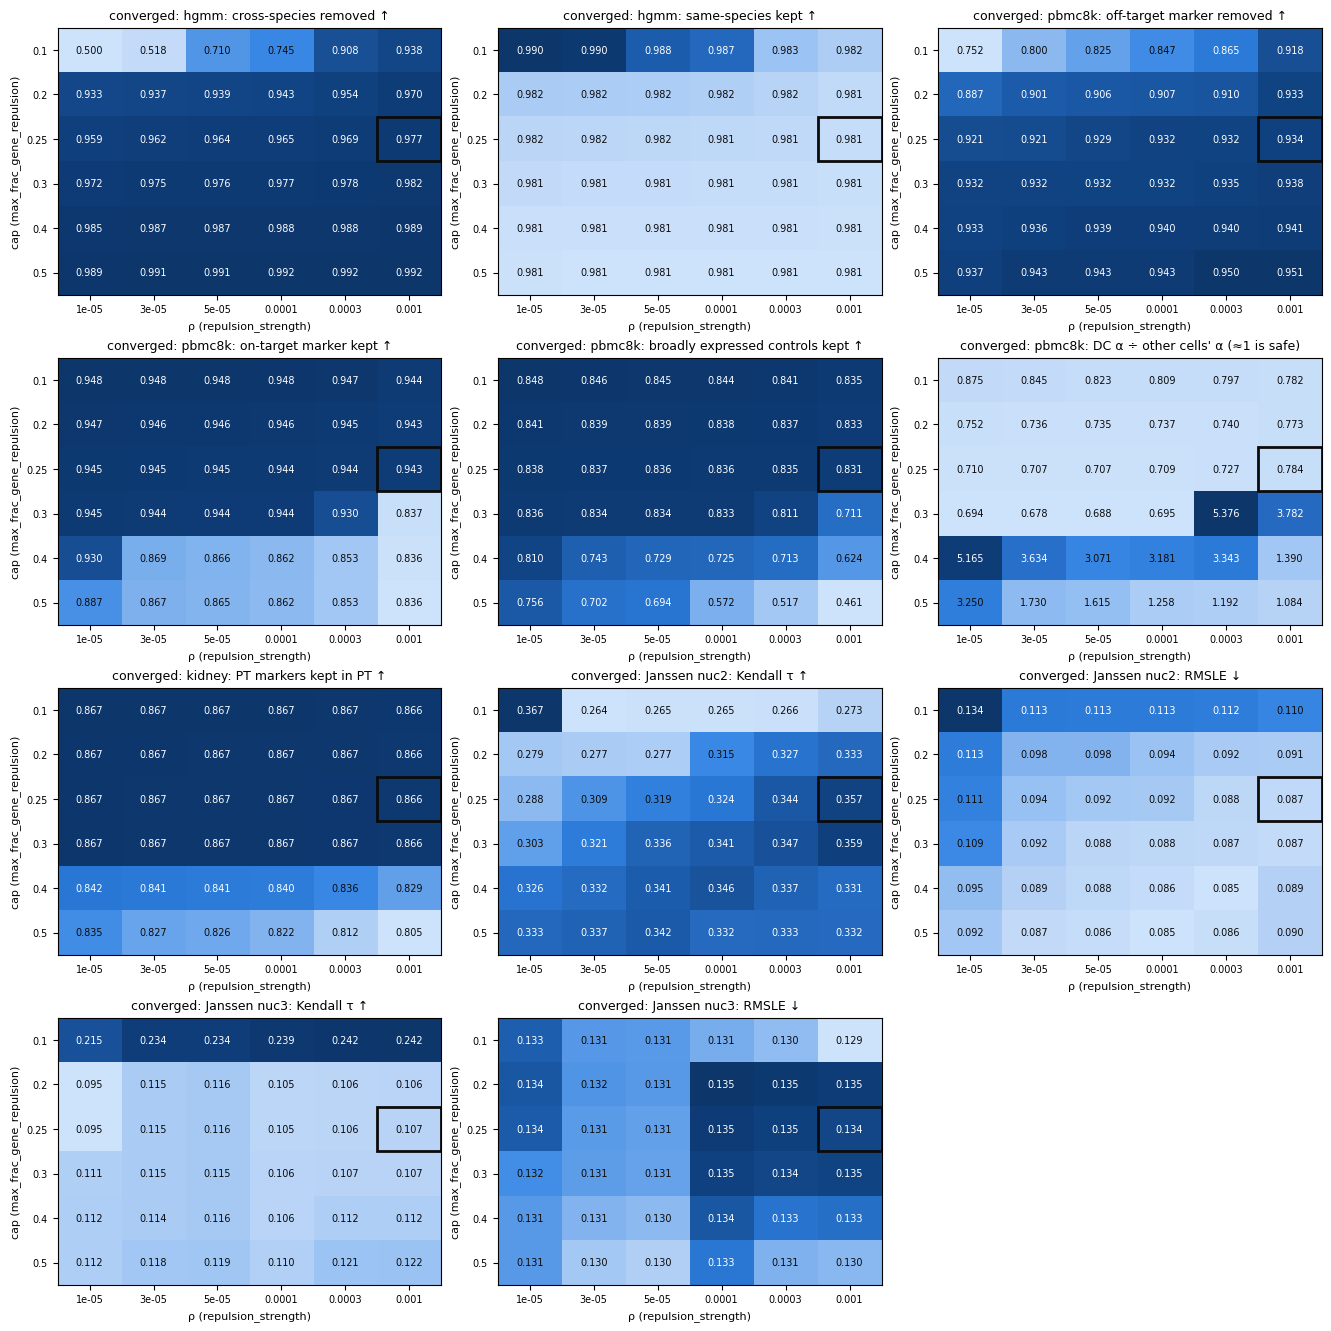

In [10]:
res = pd.read_csv(results_csv)
res = res[res["dataset"].isin(datasets)]
for c in ["rho", "kappa", "cap"]:
    res[c] = res[c].astype(float)

# Sequential blue ramp (light = low, dark = high); ordinal steps for rho in scatter plots
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
       "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ)
RHO_COLORS = ["#86b6ef", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
CAP_MARKERS = ["o", "s", "P", "^", "D", "v"]

HEADLINE = [  # (dataset, column, title)
    ("hgmm_12k", "hgmm_noise_removed", "hgmm: cross-species removed ↑"),
    ("hgmm_12k", "hgmm_signal_kept", "hgmm: same-species kept ↑"),
    ("pbmc8k", "pbmc_offtarget_removed", "pbmc8k: off-target marker removed ↑"),
    ("pbmc8k", "pbmc_ontarget_kept", "pbmc8k: on-target marker kept ↑"),
    ("pbmc8k", "pbmc_controls_kept", "pbmc8k: broadly expressed controls kept ↑"),
    ("pbmc8k", "pbmc_DC_alpha_ratio", "pbmc8k: DC α ÷ other cells' α (≈1 is safe)"),
    ("kidney_nuclei_10k", "kidney_PT_markers_kept", "kidney: PT markers kept in PT ↑"),
    ("janssen_nuc2", "janssen_tau", "Janssen nuc2: Kendall τ ↑"),
    ("janssen_nuc2", "janssen_rmsle", "Janssen nuc2: RMSLE ↓"),
    ("janssen_nuc3", "janssen_tau", "Janssen nuc3: Kendall τ ↑"),
    ("janssen_nuc3", "janssen_rmsle", "Janssen nuc3: RMSLE ↓"),
]
HEADLINE = [h for h in HEADLINE if h[0] in set(res["dataset"]) and h[1] in res.columns]


def grid(ds, col, mode, rhos, caps):
    d = res[(res.dataset == ds) & (res["mode"] == mode) & np.isclose(res.kappa, default["kappa"])]
    g = d.pivot_table(index="cap", columns="rho", values=col)
    return g.reindex(index=caps, columns=rhos)


def heatmap(ax, g, title, fmt="{:.3f}"):
    vals = g.values.astype(float)
    finite = vals[np.isfinite(vals)]
    lo, hi = (finite.min(), finite.max()) if finite.size else (0, 1)
    ax.imshow(vals, cmap=SEQ_CMAP, vmin=lo, vmax=hi if hi > lo else lo + 1e-9, aspect="auto")
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if np.isfinite(vals[i, j]):
                shade = (vals[i, j] - lo) / (hi - lo) if hi > lo else 0
                ax.text(j, i, fmt.format(vals[i, j]), ha="center", va="center", fontsize=7,
                        color="white" if shade > 0.55 else "#0b0b0b")
    rhos, caps = list(g.columns), list(g.index)
    if default["rho"] in rhos and default["cap"] in caps:
        di, dj = caps.index(default["cap"]), rhos.index(default["rho"])
        ax.add_patch(Rectangle((dj - 0.5, di - 0.5), 1, 1, fill=False, edgecolor="#0b0b0b", lw=2))
    ax.set_xticks(range(len(rhos)), [f"{r:g}" for r in rhos], fontsize=7)
    ax.set_yticks(range(len(caps)), [f"{c:g}" for c in caps], fontsize=7)
    ax.set_xlabel("ρ (repulsion_strength)", fontsize=8)
    ax.set_ylabel("cap (max_frac_gene_repulsion)", fontsize=8)
    ax.set_title(title, fontsize=9)


def heatmap_panel(kind):
    n = len(HEADLINE)
    ncol = 3
    fig, axes = plt.subplots(int(np.ceil(n / ncol)), ncol, figsize=(4.4 * ncol, 3.3 * np.ceil(n / ncol)),
                             constrained_layout=True, squeeze=False)
    for ax, (ds, col, title) in zip(axes.flat, HEADLINE):
        if kind == "long":
            heatmap(ax, grid(ds, col, "long", coarse_rho, coarse_cap), f"converged: {title}")
        elif kind == "stability":
            gap = (grid(ds, col, "long", coarse_rho, coarse_cap) - grid(ds, col, "default", coarse_rho, coarse_cap)).abs()
            heatmap(ax, gap, f"|converged − default|: {title}")
        else:
            heatmap(ax, grid(ds, col, "default", dense_rho, dense_cap), f"default stopping: {title}")
    for ax in axes.flat[n:]:
        ax.axis("off")
    fig.savefig(os.path.join(out_dir, f"heatmaps_{kind}.png"), dpi=300, bbox_inches="tight")
    plt.show()


heatmap_panel("long")

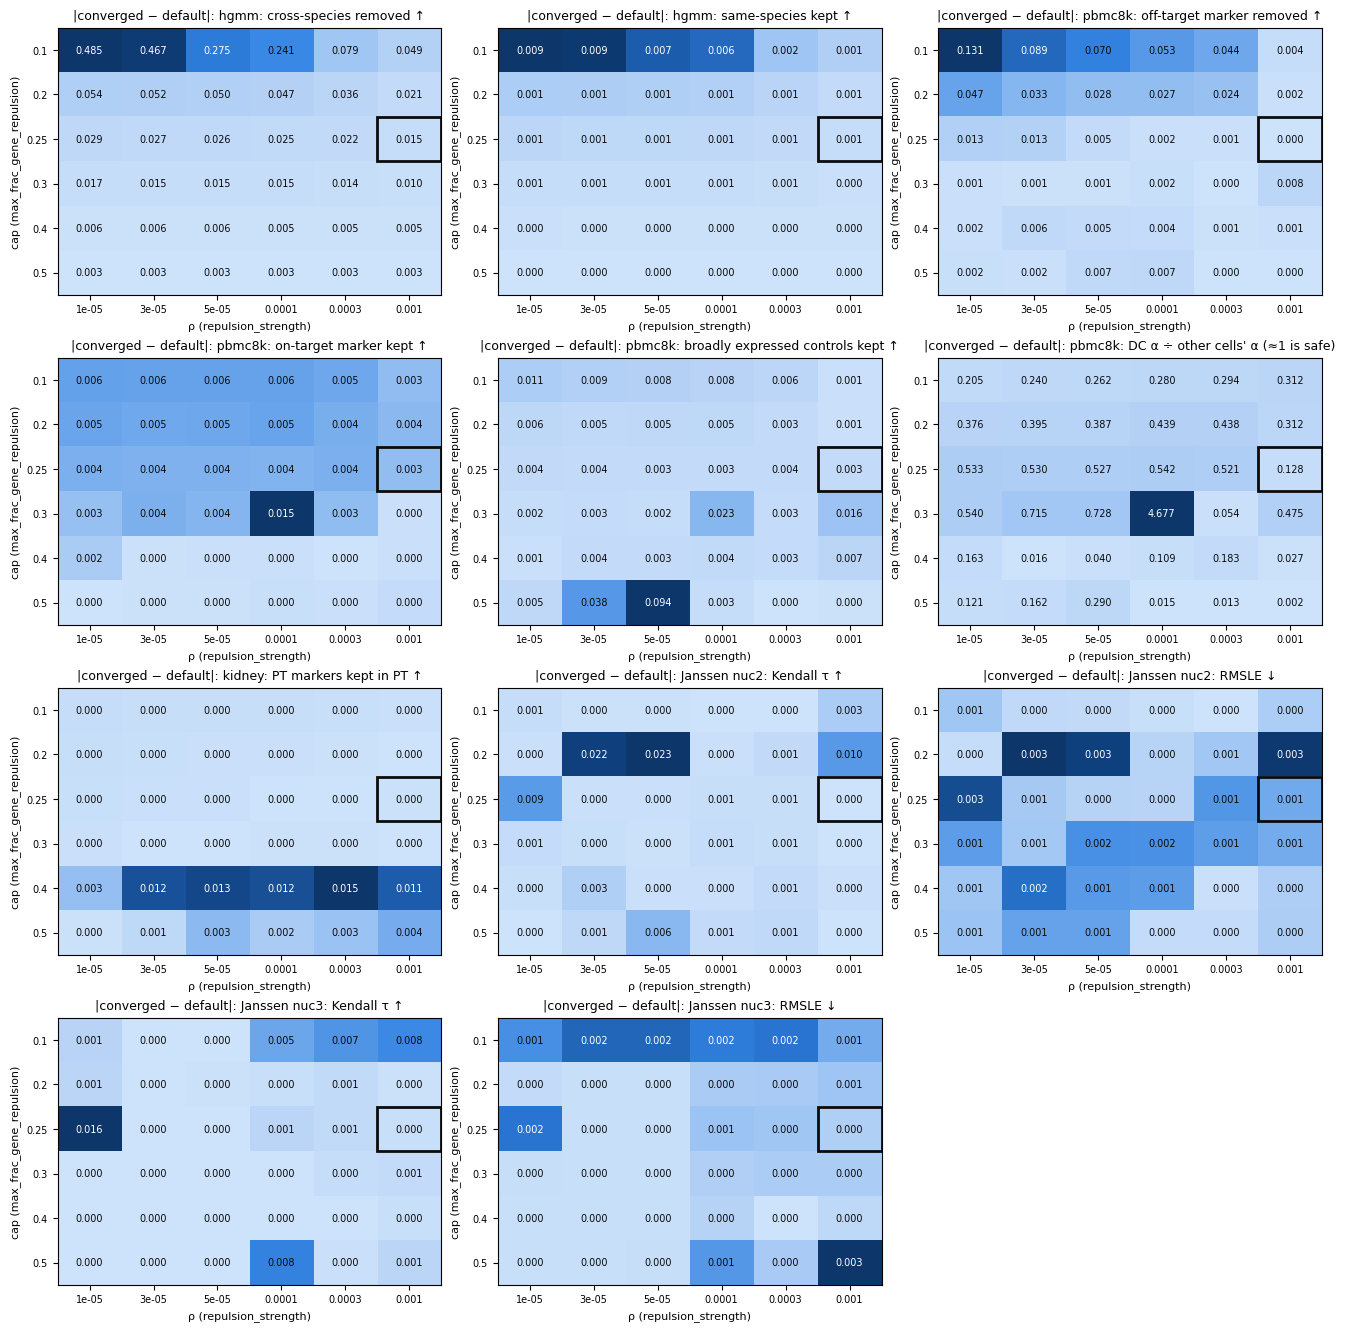

In [11]:
heatmap_panel("stability")

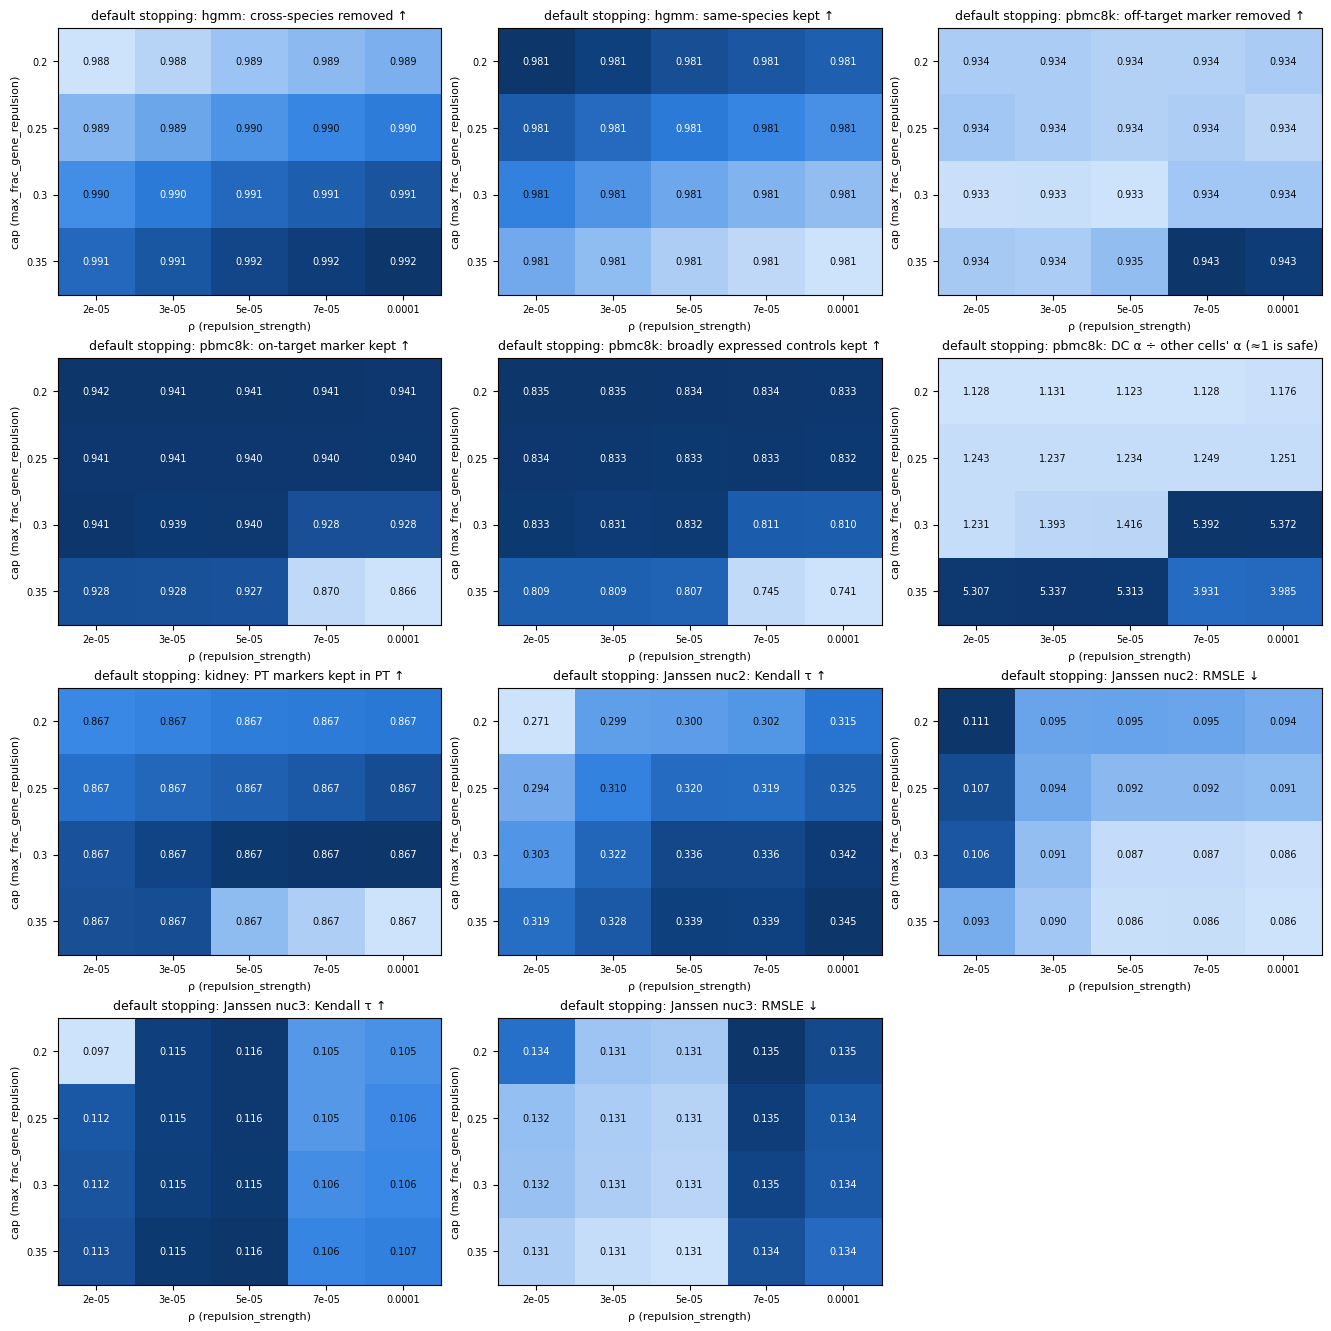

In [12]:
heatmap_panel("dense")

### Trade-off: noise removed vs signal kept

One point per (ρ, cap) setting from the coarse grid at convergence (κ = 1e-2). Color steps with ρ
(light = weak repulsion, dark = strong), marker shape encodes the cap, and the default setting is
ringed. Points further up and to the right are better.

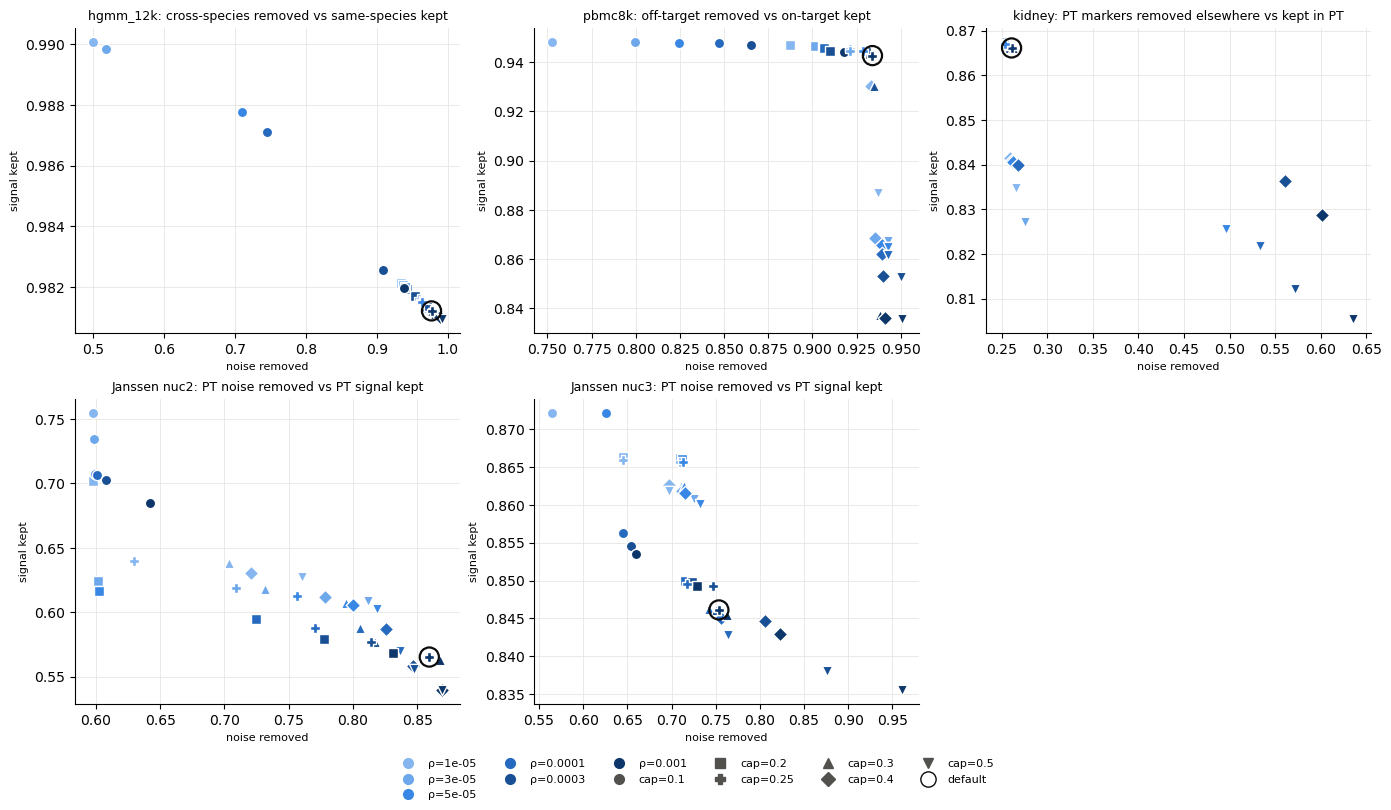

In [13]:
TRADEOFF = [(ds, x, y, t) for ds, x, y, t in [
    ("hgmm_12k", "hgmm_noise_removed", "hgmm_signal_kept", "hgmm_12k: cross-species removed vs same-species kept"),
    ("pbmc8k", "pbmc_offtarget_removed", "pbmc_ontarget_kept", "pbmc8k: off-target removed vs on-target kept"),
    ("kidney_nuclei_10k", "kidney_PT_markers_removed_elsewhere", "kidney_PT_markers_kept", "kidney: PT markers removed elsewhere vs kept in PT"),
    ("janssen_nuc2", "janssen_pt_noise_removed", "janssen_pt_signal_kept", "Janssen nuc2: PT noise removed vs PT signal kept"),
    ("janssen_nuc3", "janssen_pt_noise_removed", "janssen_pt_signal_kept", "Janssen nuc3: PT noise removed vs PT signal kept"),
] if ds in set(res["dataset"]) and x in res.columns]

ncol = 3
fig, axes = plt.subplots(int(np.ceil(len(TRADEOFF) / ncol)), ncol, figsize=(4.6 * ncol, 4.0 * np.ceil(len(TRADEOFF) / ncol)),
                         constrained_layout=True, squeeze=False)
for ax, (ds, x, y, title) in zip(axes.flat, TRADEOFF):
    d = res[(res.dataset == ds) & (res["mode"] == "long") & np.isclose(res.kappa, default["kappa"])
            & res.rho.isin(coarse_rho) & res.cap.isin(coarse_cap)]
    for _, r in d.iterrows():
        ax.scatter(r[x], r[y], s=55, color=RHO_COLORS[coarse_rho.index(r.rho)],
                   marker=CAP_MARKERS[coarse_cap.index(r.cap)], edgecolor="white", linewidth=1, zorder=3)
    dd = d[np.isclose(d.rho, default["rho"]) & np.isclose(d.cap, default["cap"])]
    ax.scatter(dd[x], dd[y], s=190, facecolor="none", edgecolor="#0b0b0b", linewidth=1.6, zorder=4)
    ax.set_xlabel("noise removed", fontsize=8)
    ax.set_ylabel("signal kept", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(color="#e6e5e1", lw=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.flat[len(TRADEOFF):]:
    ax.axis("off")

handles = [Line2D([], [], marker="o", ls="", color=c, markersize=7, label=f"ρ={r:g}") for r, c in zip(coarse_rho, RHO_COLORS)]
handles += [Line2D([], [], marker=m, ls="", color="#52514e", markersize=7, label=f"cap={c:g}") for c, m in zip(coarse_cap, CAP_MARKERS)]
handles += [Line2D([], [], marker="o", ls="", markerfacecolor="none", markeredgecolor="#0b0b0b", markersize=11, label="default")]
fig.legend(handles=handles, loc="outside lower center", ncol=6, frameon=False, fontsize=8)
fig.savefig(os.path.join(out_dir, "tradeoff_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()

### β prior strength

κ swept at the default ρ and cap. κ = 0 is the maximum-likelihood β, and larger κ holds β̂ closer
to 0.01.

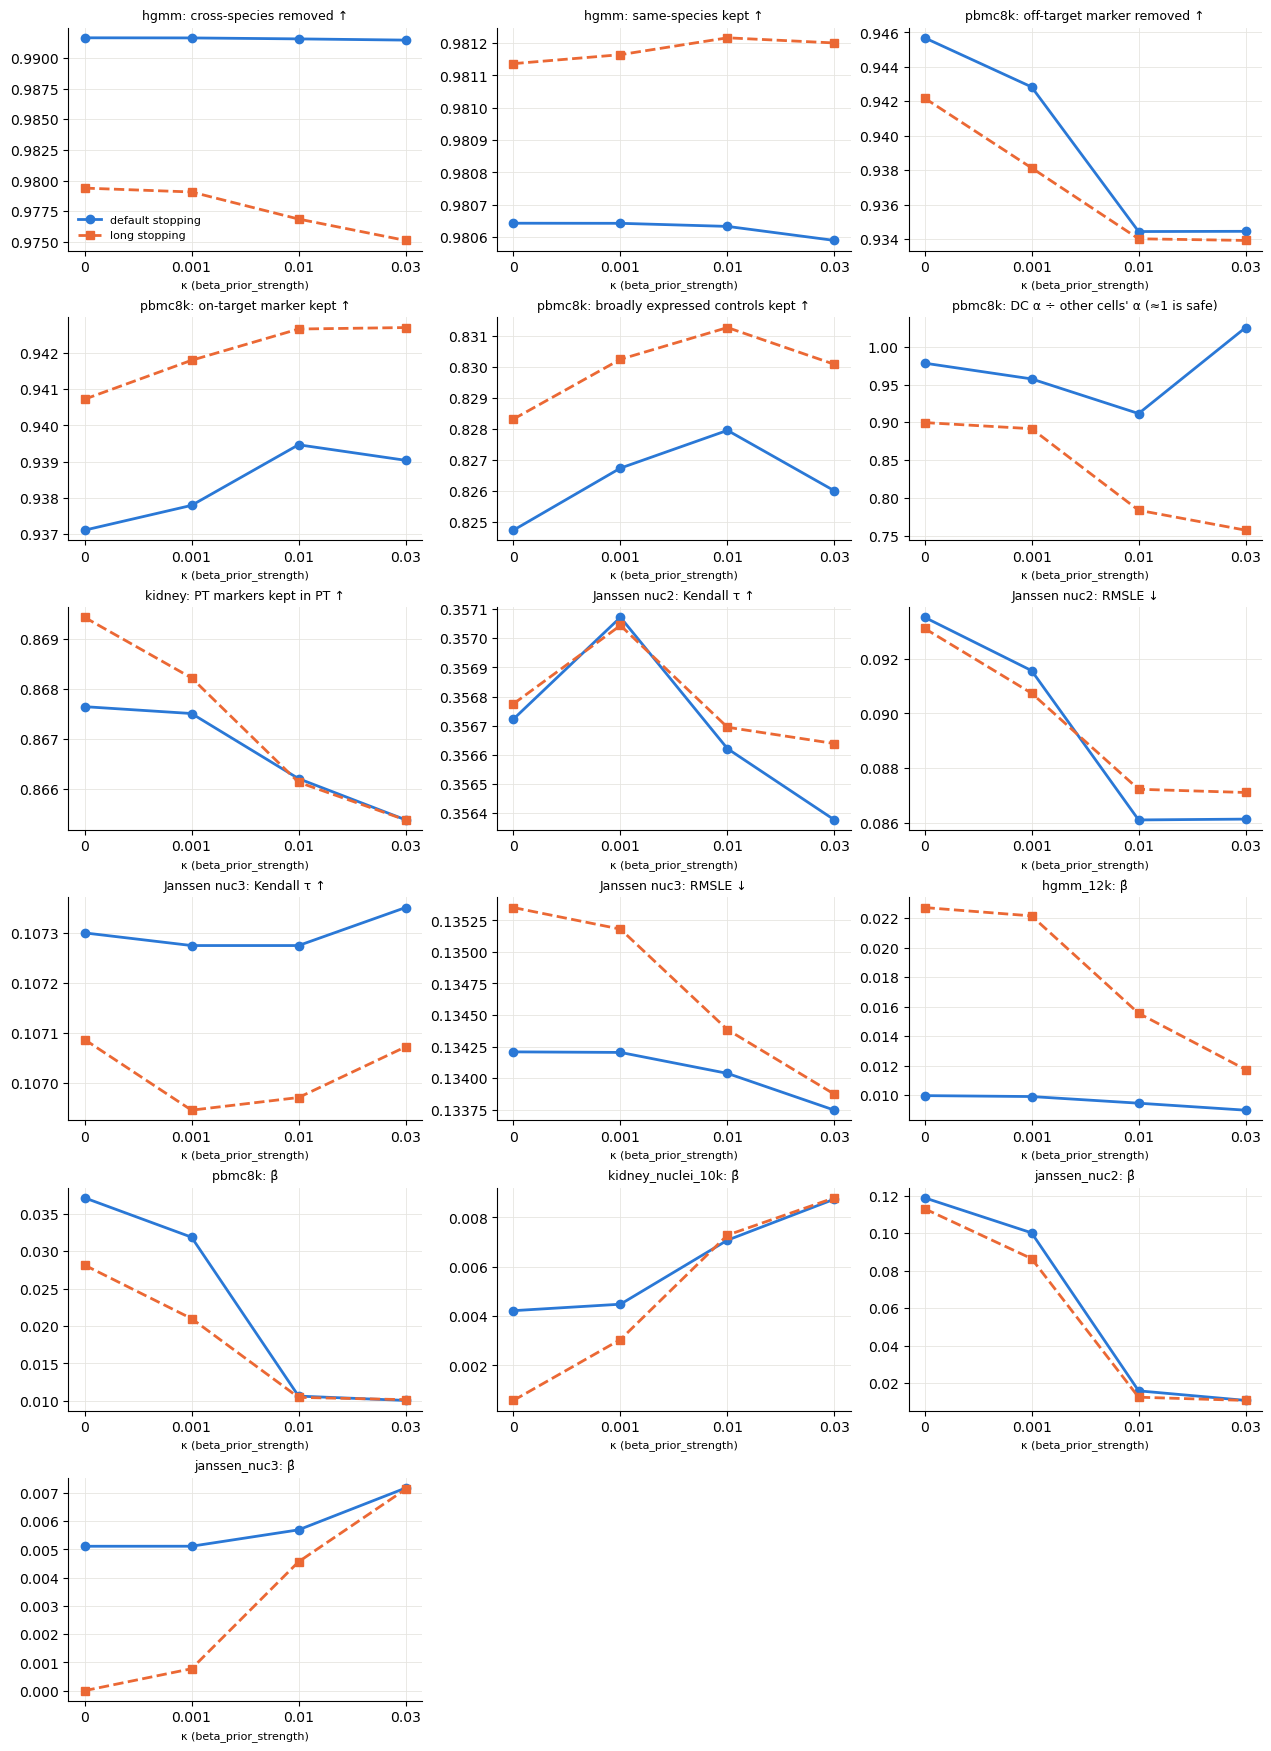

In [14]:
k_rows = res[np.isclose(res.rho, default["rho"]) & np.isclose(res.cap, default["cap"]) & res.kappa.isin(kappa_grid)]
panels = HEADLINE + [(ds, "beta_hat", f"{ds}: β̂") for ds in datasets if ds in set(res["dataset"])]
ncol = 3
fig, axes = plt.subplots(int(np.ceil(len(panels) / ncol)), ncol, figsize=(4.2 * ncol, 2.9 * np.ceil(len(panels) / ncol)),
                         constrained_layout=True, squeeze=False)
xpos = {k: i for i, k in enumerate(kappa_grid)}
for ax, (ds, col, title) in zip(axes.flat, panels):
    for mode, color, style in [("default", "#2a78d6", "-o"), ("long", "#eb6834", "--s")]:
        d = k_rows[(k_rows.dataset == ds) & (k_rows["mode"] == mode)].sort_values("kappa")
        ax.plot([xpos[k] for k in d.kappa], d[col], style, color=color, lw=2, markersize=6, label=f"{mode} stopping")
    ax.set_xticks(range(len(kappa_grid)), [f"{k:g}" for k in kappa_grid])
    ax.set_xlabel("κ (beta_prior_strength)", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(color="#e6e5e1", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.flat[len(panels):]:
    ax.axis("off")
axes.flat[0].legend(frameon=False, fontsize=8)
fig.savefig(os.path.join(out_dir, "kappa_sweep.png"), dpi=300, bbox_inches="tight")
plt.show()

### Summary table

Every setting and metric, with the default setting first. The table is descriptive: use it with
the plots above to judge how much each dataset's results move across the grid.

In [15]:
metric_cols = [c for c in res.columns if c not in ("dataset", "rho", "kappa", "cap", "mode", "seconds")
               and not c.startswith("kidney_removed_")]
summary = res.copy()
summary["is_default"] = (np.isclose(summary.rho, default["rho"]) & np.isclose(summary.kappa, default["kappa"])
                         & np.isclose(summary.cap, default["cap"]))
summary = summary.sort_values(["dataset", "mode", "is_default", "rho", "cap", "kappa"],
                              ascending=[True, True, False, True, True, True])
summary.to_csv(os.path.join(out_dir, "summary.csv"), index=False)
with pd.option_context("display.max_rows", 500, "display.max_columns", 50, "display.width", 250):
    for ds in datasets:
        d = summary[summary.dataset == ds].dropna(axis=1, how="all")
        cols = ["rho", "kappa", "cap", "mode", "is_default"] + [c for c in metric_cols if c in d.columns]
        print(f"=== {ds} ===")
        display(d[cols].round(4))

=== hgmm_12k ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,hgmm_noise_removed,hgmm_signal_kept
433,0.0010,0.010,0.25,default,True,0.0095,0.0278,0.1070,33,0.9916,0.9806
47,0.0000,0.010,0.10,default,False,0.0094,0.0275,0.1068,33,0.9846,0.9807
0,0.0000,0.000,0.20,default,False,0.0099,0.0271,0.1069,33,0.9875,0.9807
2,0.0000,0.001,0.20,default,False,0.0099,0.0272,0.1069,33,0.9875,0.9807
4,0.0000,0.010,0.20,default,False,0.0094,0.0276,0.1069,33,0.9874,0.9807
6,0.0000,0.030,0.20,default,False,0.0089,0.0281,0.1069,33,0.9871,0.9806
455,0.0000,0.010,0.25,default,False,0.0094,0.0277,0.1069,33,0.9883,0.9807
49,0.0000,0.010,0.30,default,False,0.0094,0.0277,0.1069,33,0.9892,0.9807
51,0.0000,0.010,0.40,default,False,0.0094,0.0277,0.1070,33,0.9907,0.9806
53,0.0000,0.010,0.50,default,False,0.0095,0.0278,0.1070,33,0.9921,0.9806


=== pbmc8k ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,pbmc_offtarget_removed,pbmc_ontarget_kept,pbmc_controls_kept,pbmc_DC_median_alpha,pbmc_DC_alpha_ratio
438,0.0010,0.010,0.25,default,True,0.0106,0.0674,0.1433,840,0.9344,0.9395,0.8280,0.0616,0.9116
112,0.0000,0.010,0.10,default,False,0.0145,0.0549,0.1359,371,0.8834,0.9426,0.8369,0.0593,1.0809
114,0.0000,0.010,0.20,default,False,0.0157,0.0558,0.1377,383,0.9339,0.9418,0.8351,0.0629,1.1285
465,0.0000,0.010,0.25,default,False,0.0167,0.0563,0.1390,388,0.9344,0.9410,0.8337,0.0696,1.2431
116,0.0000,0.010,0.30,default,False,0.0136,0.0593,0.1388,485,0.9331,0.9416,0.8336,0.0728,1.2347
118,0.0000,0.010,0.40,default,False,0.0150,0.0659,0.1571,480,0.9351,0.9283,0.8083,0.3434,5.3281
120,0.0000,0.010,0.50,default,False,0.0144,0.1149,0.2072,469,0.9397,0.8869,0.7515,0.3448,3.1299
171,0.0000,0.010,0.20,default,False,0.0162,0.0556,0.1379,398,0.9340,0.9416,0.8349,0.0626,1.1285
172,0.0000,0.010,0.25,default,False,0.0166,0.0566,0.1392,416,0.9343,0.9406,0.8335,0.0701,1.2427
173,0.0000,0.010,0.30,default,False,0.0126,0.0614,0.1397,541,0.9328,0.9412,0.8326,0.0753,1.2308


=== kidney_nuclei_10k ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,kidney_PT_markers_kept,kidney_PT_markers_removed_elsewhere
443,0.0010,0.010,0.25,default,True,0.0071,0.1041,0.1788,453,0.8662,0.2695
191,0.0000,0.010,0.10,default,False,0.0079,0.1002,0.1767,301,0.8671,0.2598
193,0.0000,0.010,0.20,default,False,0.0079,0.1008,0.1772,307,0.8667,0.2607
475,0.0000,0.010,0.25,default,False,0.0078,0.1011,0.1772,312,0.8668,0.2612
195,0.0000,0.010,0.30,default,False,0.0075,0.1014,0.1772,321,0.8669,0.2621
197,0.0000,0.010,0.40,default,False,0.0065,0.1427,0.2101,339,0.8387,0.2676
199,0.0000,0.010,0.50,default,False,0.0066,0.1497,0.2154,364,0.8347,0.2751
250,0.0000,0.010,0.20,default,False,0.0078,0.1012,0.1772,313,0.8668,0.2611
251,0.0000,0.010,0.25,default,False,0.0076,0.1014,0.1773,322,0.8668,0.2619
252,0.0000,0.010,0.30,default,False,0.0074,0.1019,0.1775,333,0.8669,0.2645


=== janssen_nuc2 ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,janssen_n,janssen_tau,janssen_rmsle,janssen_median_estimate,janssen_median_truth,janssen_pt_noise_removed,janssen_pt_signal_kept,janssen_constitutive_kept
448,0.0010,0.010,0.25,default,True,0.0158,0.4238,0.4117,517,1514.0,0.3566,0.0861,0.3694,0.3312,0.8608,0.5602,0.6189
270,0.0000,0.010,0.10,default,False,0.0085,0.2392,0.2402,828,1514.0,0.3660,0.1339,0.2148,0.3312,0.5984,0.7484,0.7763
272,0.0000,0.010,0.20,default,False,0.0089,0.2920,0.2864,1192,1514.0,0.2797,0.1124,0.2986,0.3312,0.5987,0.6852,0.7374
485,0.0000,0.010,0.25,default,False,0.0109,0.3399,0.3291,474,1514.0,0.2976,0.1082,0.3027,0.3312,0.6855,0.6377,0.6976
274,0.0000,0.010,0.30,default,False,0.0104,0.3430,0.3311,532,1514.0,0.3036,0.1078,0.3041,0.3312,0.7065,0.6367,0.6955
276,0.0000,0.010,0.40,default,False,0.0102,0.3455,0.3361,613,1514.0,0.3268,0.0946,0.3097,0.3312,0.7232,0.6296,0.6894
278,0.0000,0.010,0.50,default,False,0.0130,0.3476,0.3411,453,1514.0,0.3336,0.0917,0.3120,0.3312,0.7626,0.6256,0.6820
330,0.0000,0.010,0.20,default,False,0.0095,0.3426,0.3311,876,1514.0,0.2712,0.1110,0.3119,0.3312,0.6119,0.6340,0.7000
331,0.0000,0.010,0.25,default,False,0.0106,0.3531,0.3411,535,1514.0,0.2937,0.1073,0.3187,0.3312,0.6986,0.6269,0.6885
332,0.0000,0.010,0.30,default,False,0.0101,0.3546,0.3423,698,1514.0,0.3027,0.1056,0.3198,0.3312,0.7240,0.6271,0.6875


=== janssen_nuc3 ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,janssen_n,janssen_tau,janssen_rmsle,janssen_median_estimate,janssen_median_truth,janssen_pt_noise_removed,janssen_pt_signal_kept,janssen_constitutive_kept
453,0.0010,0.010,0.25,default,True,0.0057,0.1497,0.2062,258,398.0,0.1073,0.1340,0.1254,0.1795,0.7616,0.8453,0.8522
350,0.0000,0.010,0.10,default,False,0.0051,0.1334,0.1715,424,398.0,0.2161,0.1321,0.0845,0.1795,0.5878,0.8697,0.8839
352,0.0000,0.010,0.20,default,False,0.0050,0.1383,0.1791,523,398.0,0.0964,0.1336,0.1142,0.1795,0.6485,0.8660,0.8765
495,0.0000,0.010,0.25,default,False,0.0051,0.1403,0.1814,381,398.0,0.1111,0.1318,0.1148,0.1795,0.6950,0.8652,0.8746
354,0.0000,0.010,0.30,default,False,0.0051,0.1405,0.1817,382,398.0,0.1113,0.1317,0.1148,0.1795,0.6964,0.8621,0.8744
356,0.0000,0.010,0.40,default,False,0.0052,0.1408,0.1820,385,398.0,0.1118,0.1313,0.1153,0.1795,0.6977,0.8619,0.8739
358,0.0000,0.010,0.50,default,False,0.0052,0.1410,0.1821,390,398.0,0.1119,0.1313,0.1153,0.1795,0.6979,0.8611,0.8738
410,0.0000,0.010,0.20,default,False,0.0051,0.1383,0.1790,648,398.0,0.0965,0.1336,0.1143,0.1795,0.6487,0.8660,0.8766
411,0.0000,0.010,0.25,default,False,0.0051,0.1405,0.1819,396,398.0,0.1116,0.1316,0.1148,0.1795,0.6996,0.8626,0.8743
412,0.0000,0.010,0.30,default,False,0.0051,0.1408,0.1821,401,398.0,0.1120,0.1316,0.1148,0.1795,0.7025,0.8619,0.8742
